In [1]:
import numpy as np
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


def BivariateCorrelation(preds, targets):
    '''Compute the Bivariate Correlation'''
    num = ((preds[:,0] * targets[:,0]) + (preds[:,1] * targets[:,1])).sum()
    denom1 = np.sqrt(((preds[:,0] * preds[:,0]) + (preds[:,1] * preds[:,1])).sum())
    denom2 = np.sqrt(((targets[:,0] * targets[:,0]) + (targets[:,1] * targets[:,1])).sum())
    return num/(denom1*denom2)

In [2]:
import netCDF4 as nc

ERA5_PC = '/glade/campaign/univ/uchi0014/benchmark-dev/MJO/MJO_PC_INDEX_ERA5.nc'
f_era5  = nc.Dataset(ERA5_PC)
print(f_era5)
pc1_std = np.array(f_era5['PC1_std'])
pc2_std = np.array(f_era5['PC2_std'])
pc1_era5 = np.array(f_era5['PC1']) * pc1_std
pc2_era5 = np.array(f_era5['PC2']) * pc2_std
yyyymmdd = f_era5['yyyymmdd']
print(yyyymmdd[0])


<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    dimensions(sizes): time(2556), ncl1(2556), ncl2(1), ncl3(1)
    variables(dimensions): float32 MJO_INDEX(time), float64 time(time), float32 PC1(time), float32 PC2(time), int32 yyyymmdd(ncl1), float32 PC1_std(ncl2), float32 PC2_std(ncl3)
    groups: 
20170101


/glade/derecho/scratch/bgong/tmp/ipykernel_118403/3197986587.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pc1_std = np.array(f_era5['PC1_std'])
/glade/derecho/scratch/bgong/tmp/ipykernel_118403/3197986587.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pc2_std = np.array(f_era5['PC2_std'])
/glade/derecho/scratch/bgong/tmp/ipykernel_118403/3197986587.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __a

In [3]:
# load predictions
import glob

preds_cases = []
targets_cases = []

for file in sorted(glob.glob('/glade/campaign/univ/uchi0014/benchmark-dev/MJO/cal_pc/MJO_PC_INDEX_PRED*.nc')):
    print('working on', file)
    f_s2s  = nc.Dataset(file)
    pc1_std_s2s = np.array(f_s2s['PC1_std'])
    pc2_std_s2s = np.array(f_s2s['PC2_std'])
    pc1_s2s = np.array(f_s2s['PC1']) * pc1_std_s2s
    pc2_s2s = np.array(f_s2s['PC2']) * pc2_std_s2s
    preds = np.zeros((len(pc1_s2s), 2))
    preds[:, 0] = pc1_s2s
    preds[:, 1] = pc2_s2s

    preds_cases.append(preds)
    YMDp = f_s2s['YMDp']
    #print(YMDp)
    index = np.where(yyyymmdd == YMDp[0])[0][0]
    targets = np.zeros((len(pc1_s2s), 2))
    targets[:, 0] = pc1_era5[index:index+len(pc1_s2s)]
    targets[:, 1] = pc2_era5[index:index+len(pc1_s2s)]
    targets_cases.append(targets)

print(np.shape(preds_cases))
print(np.shape(targets_cases))

preds_cases = np.array(preds_cases)
targets_cases = np.array(targets_cases)

BC = np.zeros((np.shape(preds_cases)[1], 1))

for i in range(np.shape(preds_cases)[1]):
    BC[i] = BivariateCorrelation(np.array(preds_cases[:, i, :]), np.array(targets_cases[:, i, :]))

print(BC)

working on /glade/campaign/univ/uchi0014/benchmark-dev/MJO/cal_pc/MJO_PC_INDEX_PRED_20190501ens_1.nc
working on /glade/campaign/univ/uchi0014/benchmark-dev/MJO/cal_pc/MJO_PC_INDEX_PRED_20190502ens_1.nc
working on /glade/campaign/univ/uchi0014/benchmark-dev/MJO/cal_pc/MJO_PC_INDEX_PRED_20190503ens_1.nc
working on /glade/campaign/univ/uchi0014/benchmark-dev/MJO/cal_pc/MJO_PC_INDEX_PRED_20190504ens_1.nc
working on /glade/campaign/univ/uchi0014/benchmark-dev/MJO/cal_pc/MJO_PC_INDEX_PRED_20190505ens_1.nc
working on /glade/campaign/univ/uchi0014/benchmark-dev/MJO/cal_pc/MJO_PC_INDEX_PRED_20190506ens_1.nc
working on /glade/campaign/univ/uchi0014/benchmark-dev/MJO/cal_pc/MJO_PC_INDEX_PRED_20190507ens_1.nc
working on /glade/campaign/univ/uchi0014/benchmark-dev/MJO/cal_pc/MJO_PC_INDEX_PRED_20190508ens_1.nc
working on /glade/campaign/univ/uchi0014/benchmark-dev/MJO/cal_pc/MJO_PC_INDEX_PRED_20190509ens_1.nc
working on /glade/campaign/univ/uchi0014/benchmark-dev/MJO/cal_pc/MJO_PC_INDEX_PRED_2019051

/glade/derecho/scratch/bgong/tmp/ipykernel_118403/1905990174.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pc1_std_s2s = np.array(f_s2s['PC1_std'])
/glade/derecho/scratch/bgong/tmp/ipykernel_118403/1905990174.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pc2_std_s2s = np.array(f_s2s['PC2_std'])
/glade/derecho/scratch/bgong/tmp/ipykernel_118403/1905990174.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False fa

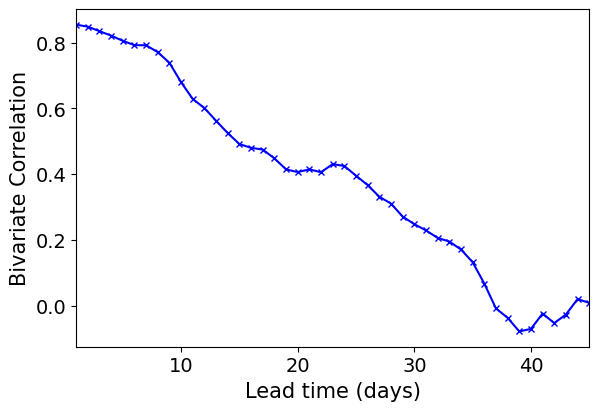

In [ ]:
time = np.linspace(1, 45, 45)

plt.rcParams["font.size"] = 14

fig,ax = plt.subplots(ncols=1,nrows=1,figsize=(6,4), constrained_layout=True)

ax.plot(time, BC[1:], color = 'blue', marker = 'x', markersize = 5)
ax.set_xlim([1, 45])
ax.set_xlabel('Lead time (days)', fontsize=15)
ax.set_ylabel('Bivariate Correlation', fontsize=15)

plt.savefig('BC.png', bbox_inches='tight')
#plt.close()